
===== FEATURES ENZO =====
AUC = 336.53
dSmO2 max = 13.02
slope = -0.521
tau = 2.51

===== LACTATE PREDICTION =====
Delta peak = 14.11
Peak lactate = 15.61
La at end of exercise (onset of recovery) = 8.75


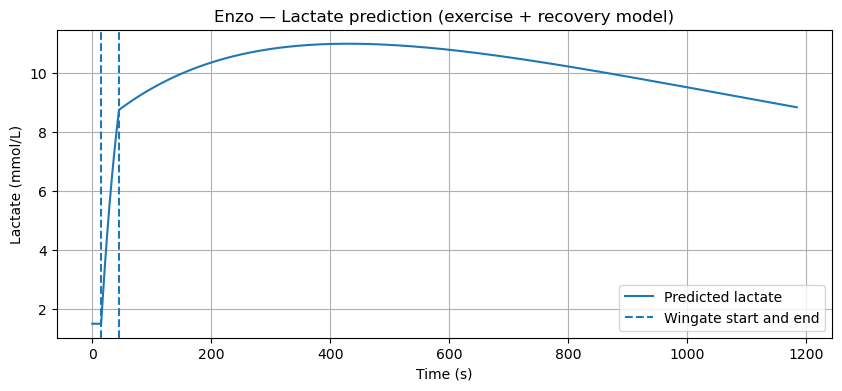

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 1) PARAMETERS
CSV_FILE = "../DATA/Enzo_wingate.csv"

START_TIME_S = 15
WINGATE_DURATION = 30
END_TIME_S = START_TIME_S + WINGATE_DURATION

# FIXED MODEL ASSUMPTIONS
T_PEAK_MIN = 3
T_PEAK_S = END_TIME_S + T_PEAK_MIN * 60

LA_BASELINE = 1.5  # assumed

# SmO2 baseline
SMO2_BASELINE = 70

# MODEL 2 COEFFICIENTS
B0 = 9.4178  # intercept
B1 = 0.011459  # AUC_30s
B2 = 0.178943  # tau_SmO2
B3 = 0.029526  # dSmO2_max
B4 = -0.012427   # slope_0_10

# Recovery kinetics for Durand et al. (2021) rewrite of Freund model
GAMMA1 = 1 / 300
GAMMA2 = 1 / 1800


# LOAD CSV
def load_csv(file_path):
    with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    header_idx = None
    for i, line in enumerate(lines):
        if "Timestamp (seconds passed)" in line and "SmO2" in line:
            header_idx = i
            break

    df = pd.read_csv(file_path, skiprows=header_idx)
    df.columns = [str(c).strip() for c in df.columns]

    df = df[["Timestamp (seconds passed)", "SmO2"]]
    df.columns = ["Time", "SmO2"]

    df["Time"] = pd.to_numeric(df["Time"], errors="coerce")
    df["SmO2"] = pd.to_numeric(df["SmO2"], errors="coerce")

    return df.dropna().sort_values("Time").reset_index(drop=True)


sm = load_csv(CSV_FILE)


# FEATURES
wing = sm[(sm["Time"] >= START_TIME_S) &
          (sm["Time"] <= END_TIME_S)].copy()

wing["t_rel"] = wing["Time"] - START_TIME_S
wing["dSmO2"] = (SMO2_BASELINE - wing["SmO2"]).clip(lower=0)

dt = np.mean(np.diff(wing["Time"]))
AUC = np.sum(wing["dSmO2"]) * dt
dmax = wing["dSmO2"].max()

early = wing[wing["t_rel"] <= 10]
slope = np.polyfit(early["t_rel"], early["SmO2"], 1)[0]

# tau estimation
def model(t, A, tau):
    return A * (1 - np.exp(-t/tau))


t = wing["t_rel"].values
y = wing["dSmO2"].values

popt, _ = curve_fit(model, t, y, p0=[y.max(), 5])
A_fit, tau = popt

print("\n===== FEATURES ENZO =====")
print(f"AUC = {AUC:.2f}")
print(f"dSmO2 max = {dmax:.2f}")
print(f"slope = {slope:.3f}")
print(f"tau = {tau:.2f}")


# MODEL 2 PREDICTION
delta_peak = B0 + B1*AUC + B2*tau + B3*dmax + B4*slope
delta_peak = max(delta_peak, 0)

la_peak = LA_BASELINE + delta_peak

print("\n===== LACTATE PREDICTION =====")
print(f"Delta peak = {delta_peak:.2f}")
print(f"Peak lactate = {la_peak:.2f}")


# CURVE MODEL
def rise(frac):
    frac = np.clip(frac, 0, 1)
    return (1 - np.exp(-5*frac)) / (1 - np.exp(-5))


def freund_recovery(t_after_recovery):
    return (
        LA_REC_ONSET
        + (delta_peak + LA_BASELINE - LA_REC_ONSET) * (1 - np.exp(-GAMMA1 * t_after_recovery))
        + (-delta_peak) * (1 - np.exp(-GAMMA2 * t_after_recovery))
    )


# Predicted lactate at end of exercise / onset of recovery
frac_end = (END_TIME_S - START_TIME_S) / (T_PEAK_S - START_TIME_S)
LA_REC_ONSET = LA_BASELINE + rise(frac_end) * delta_peak
print(f"La at end of exercise (onset of recovery) = {LA_REC_ONSET:.2f}")

pred = sm.copy()
pred["La"] = np.nan

for i, t_abs in enumerate(pred["Time"]):

    if t_abs < START_TIME_S:
        pred.loc[i, "La"] = LA_BASELINE

    elif t_abs <= END_TIME_S:
        frac = (t_abs - START_TIME_S) / (T_PEAK_S - START_TIME_S)
        pred.loc[i, "La"] = LA_BASELINE + rise(frac) * delta_peak

    else:
        t_rec = t_abs - END_TIME_S
        pred.loc[i, "La"] = freund_recovery(t_rec)


# PLOT
plt.figure(figsize=(10,4))
plt.plot(pred["Time"], pred["La"], label="Predicted lactate")
plt.axvline(START_TIME_S, linestyle="--", label="Wingate start and end")
plt.axvline(END_TIME_S, linestyle="--")
plt.xlabel("Time (s)")
plt.ylabel("Lactate (mmol/L)")
plt.title("Enzo — Lactate prediction (exercise + recovery model)")
plt.grid(True)
plt.legend()
plt.show()


===== ENZO VALIDATION TABLE =====
   Time_min  Time_abs_s  La_measured  La_predicted     Error  Absolute_error
0        -1         -45          2.6      1.500000 -1.100000        1.100000
1         0          45         15.6      8.751817 -6.848183        6.848183
2         4         285         18.6     10.769205 -7.830795        7.830795
3         6         405         13.3     10.988847 -2.311153        2.311153
4         8         525         12.0     10.924830 -1.075170        1.075170
5        12         765         12.1     10.338180 -1.761820        1.761820

===== ENZO VALIDATION METRICS =====
RMSE = 4.45 mmol/L
MAE  = 3.49 mmol/L
Bias = -3.49 mmol/L
R    = 0.84
R2   = 0.18


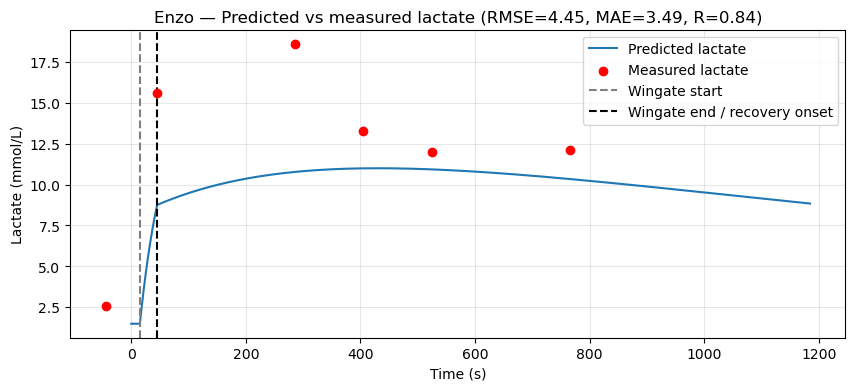

In [14]:

# VALIDATION OF THE MODEL ON ENZO


# Option 1: enter Enzo's measured lactate values directly here
enzo_measured = pd.DataFrame({
    "Time_min": [-1, 0, 4, 6, 8, 12],
    "La_measured": [2.6, 15.6, 18.6, 13.3, 12.0, 12.1]
})


def safe_pearson_r(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    if y_true.size < 2 or y_pred.size < 2:
        return np.nan
    if np.allclose(np.std(y_true), 0.0) or np.allclose(np.std(y_pred), 0.0):
        return np.nan

    return float(np.corrcoef(y_true, y_pred)[0, 1])


def safe_r2(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    ss_res = float(np.sum((y_true - y_pred) ** 2))
    ss_tot = float(np.sum((y_true - np.mean(y_true)) ** 2))
    if np.isclose(ss_tot, 0.0):
        return np.nan

    return float(1 - ss_res / ss_tot)


# Convert lactate sampling times (in minutes) to absolute SmO2 time (in seconds)
abs_times = []
for tmin in enzo_measured["Time_min"]:
    if tmin == -1:
        # baseline point placed 60 s before Wingate start
        tabs = START_TIME_S - 60
    else:
        # post-exercise samples are positioned after the end of the Wingate
        tabs = END_TIME_S + tmin * 60
    abs_times.append(tabs)

enzo_measured["Time_abs_s"] = abs_times

# Predict lactate exactly at measured sampling times using interpolation
enzo_measured["La_predicted"] = np.interp(
    enzo_measured["Time_abs_s"].to_numpy(float),
    pred["Time"].to_numpy(float),
    pred["La"].to_numpy(float),
)

enzo_measured["Error"] = enzo_measured["La_predicted"] - enzo_measured["La_measured"]
enzo_measured["Absolute_error"] = np.abs(enzo_measured["Error"])
enzo_measured["Squared_error"] = enzo_measured["Error"]**2

print("\n===== ENZO VALIDATION TABLE =====")
print(enzo_measured[[
    "Time_min",
    "Time_abs_s",
    "La_measured",
    "La_predicted",
    "Error",
    "Absolute_error"
]])

# Global validation metrics
rmse_enzo = float(np.sqrt(enzo_measured["Squared_error"].mean()))
mae_enzo = float(enzo_measured["Absolute_error"].mean())
bias_enzo = float(enzo_measured["Error"].mean())

r_enzo = safe_pearson_r(enzo_measured["La_measured"], enzo_measured["La_predicted"])
r2_enzo = safe_r2(enzo_measured["La_measured"], enzo_measured["La_predicted"])

print("\n===== ENZO VALIDATION METRICS =====")
print(f"RMSE = {rmse_enzo:.2f} mmol/L")
print(f"MAE  = {mae_enzo:.2f} mmol/L")
print(f"Bias = {bias_enzo:.2f} mmol/L")
print(f"R    = {r_enzo:.2f}" if np.isfinite(r_enzo) else "R    = nan")
print(f"R2   = {r2_enzo:.2f}" if np.isfinite(r2_enzo) else "R2   = nan")


# PLOT WITH MEASURED POINTS
plt.figure(figsize=(10, 4))
plt.plot(pred["Time"], pred["La"], label="Predicted lactate")
plt.scatter(
    enzo_measured["Time_abs_s"],
    enzo_measured["La_measured"],
    color="red",
    label="Measured lactate",
    zorder=3
)

plt.axvline(START_TIME_S, linestyle="--", label="Wingate start", color="gray")
plt.axvline(END_TIME_S, linestyle="--", color="black", label="Wingate end / recovery onset")

plt.xlabel("Time (s)")
plt.ylabel("Lactate (mmol/L)")
plt.title(
    f"Enzo — Predicted vs measured lactate "
    f"(RMSE={rmse_enzo:.2f}, MAE={mae_enzo:.2f}, R={r_enzo:.2f})"
)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()